# K-Means Clustering

This challenge will help you build an intuitive understanding of how **K-means** clustering works.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

## 1) Data Generation

To make sure our data truly contains relevant clusters, we will generate it ourselves.

To do this, we will use [`make_blobs`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) from `sklearn`.  

We want a dataset with **500 observations**, **2 features**, and **4 clusters**.  

We use *random_state=42* so you can compare results with your peers.

👇 Run the cell below to generate your data.

In [2]:
random_state=42

# Generate data
X, y = make_blobs(n_samples=500, centers=4, random_state=random_state)

❓ Create a scatter plot of your two features against each other  
❓ Color the points according to their corresponding values in `y`

<details span="markdown">
    <summary>💡 Hint</summary>

- Remember the color argument:
 - `c` for matplotlib  
 - `hue` for seaborn 

---
</details>

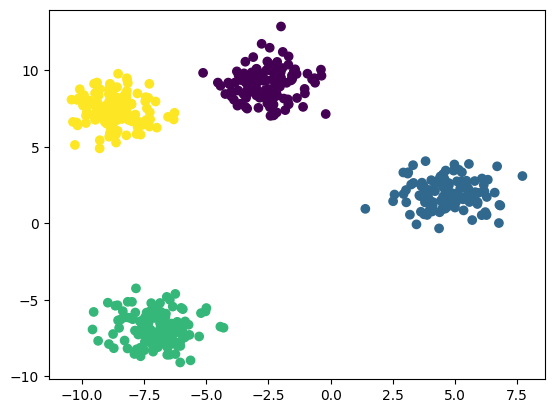

In [8]:
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap='viridis'
)
plt.show()

👆 You should see 4 distinct clusters, each in a different color.  

Training a KNN Classifier on `X` with target `y` would yield great results.

But today we will talk about **Unsupervised Learning**.  

Let's assume we know nothing about `y` and we only received `X` to work with.  

We only have 2 features and no target 😱  

**What can we do with just `X`?**  🤔

## 2) Apply K-Means

Your goal is to find the **number of clusters** that best fits the structure of your data.


👉 Import `KMeans` from `sklearn` and initialize a model with the following parameters:
- `n_clusters=2`,
- `random_state=42`

❓ Fit the model to your `X`  
❓ Get the predictions and store them in a variable called `y_pred`.  

In [9]:
from sklearn.cluster import KMeans

model_kmeans = KMeans(n_clusters=2, random_state=42)
model_kmeans.fit(X)

y_pred = model_kmeans.predict(X)


👆 The predictions are a vector of cluster assignments for each observation.  
With `n_clusters=2`, each observation in `X` will be assigned to one of two clusters.

❓ Create a scatter plot of your two features against each other
❓ Color the points according to the predicted cluster in `y_pred`

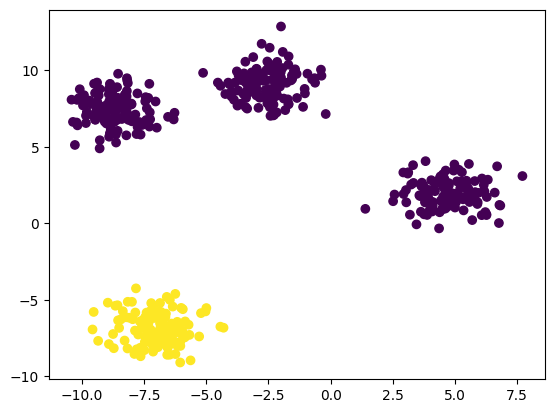

In [10]:
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_pred,
    cmap='viridis'
)
plt.show()

👆 You can still see 4 distinct clusters, but the colors only show 2 of them. 😱

This is exactly what we asked for when we gave **KMeans** `n_clusters=2`.

We asked our algorithm to assign each observation to one of two centers, and therefore only one of two clusters.

**This clustering around 2 centers is clearly not optimal — we can do better** 💪

### 🧪 Test Your Code

In [11]:
from nbresult import ChallengeResult

result = ChallengeResult('two_means', clusters=y_pred)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-image-compressor/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 2 items

test_two_means.py::TestTwoMeans::test_imbalanced_clusters PASSED         [ 50%]
test_two_means.py::TestTwoMeans::test_two_clusters PASSED                [100%]

============================== 2 passed in 0.14s ===============================


💯 You can commit your code:

git add tests/two_means.pickle

git commit -m 'Completed two_means step'

git push origin master



## 3) Find the Optimal Number of Clusters   
*Elbow Method*

Once fitted, a `KMeans` instance gains an attribute called `inertia_`.

This attribute represents the **sum of squared distances of observations to their closest cluster center**. 

Therefore, the lower the value, the better.  

In [12]:
KMeans(n_clusters=2, random_state=random_state).fit(X).inertia_

15737.083577865003

👆 Think of this in comparison with the sum of squared errors in linear regression 👇

- `SSE` of `Linear Regression` 👉 `Sum of squared distances between observations and the regression line`

- `Inertia` of `KMeans clustering` 👉 `Sum of squared distances between observations and their closest centroid`

One way to find the optimal number of clusters is a heuristic method called the **Elbow Method**.  

We should try a few values for the number of clusters and examine the inertia obtained for each.  

By doing this, we can develop an intuitive idea! ⚙️🧠

❓ Fit a `KMeans` for each number of clusters from 1 to 10 and store the inertia for each in a list called `wcss`

In [13]:
# Apply the elbow method to find the optimal number of clusters.
wcss = []
clusters = list(range(1, 11))
wcss = [KMeans(n_clusters=k, random_state=42).fit(X).inertia_ for k in clusters]

❓ Plot the inertia values in `wcss` against their corresponding number of clusters 

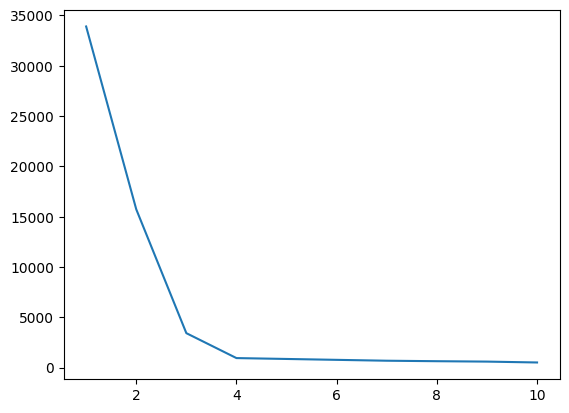

In [15]:
plt.plot(clusters, wcss)
plt.show()

👆 We can clearly see an Elbow at 4 clusters.  

## 3) K-Means with Optimal Clusters

Now that the optimal number of clusters is known, it's time for one final `KMeans` fit.

❓ Fit a `KMeans` on `X` with `n_clusters=4` and store the predictions in `y_pred`  

❓ Create a scatter plot of your two features against each other and color the points according to the predicted cluster in `y_pred`

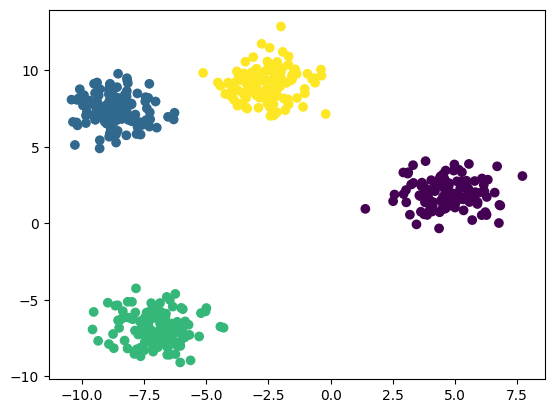

In [20]:
y_pred = KMeans(n_clusters=4, random_state=42).fit_predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_pred,
    cmap='viridis'
)

This is a prime example of clustering 🏆
We successfully identified **4 clusters** among our observations.  

**Notes:** Scaling features before clustering is not always necessary, but it rarely hurts 😇
For more information, check out these [detailed answers](https://datascience.stackexchange.com/questions/6715/is-it-necessary-to-standardize-your-data-before-clustering).

🏁 **Don't forget to push the notebook.**  

Complete the day's tasks and come back here if you have time 😉

## 4 - Optional) Hierarchical Clustering

Another method to help us find the optimal number of clusters is **[Hierarchical Clustering](https://en.wikipedia.org/wiki/Hierarchical_clustering)**.

👉 Plot the **dendrogram** of the hierarchical clustering.

To do this, you will need two classes from SciPy's  
[`cluster.hierarchy`](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html) module:

- [`linkage`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage)  
- [`dendrogram`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html#scipy.cluster.hierarchy.dendrogram)

The `linkage` function performs hierarchical clustering using a **bottom-up** approach:  
Each observation starts in its own cluster.

At each iteration, the algorithm selects the pair of clusters to merge.  
The final iteration is the step where all observations are gathered into a single cluster.

The **Ward method** will be used here. This method aims to minimize the total within-cluster variance.  
At each step, the algorithm selects the two clusters whose merge increases within-cluster variance the least.

A **dendrogram** is a diagram representing a tree-like structure that allows us to visualize this linkage process.


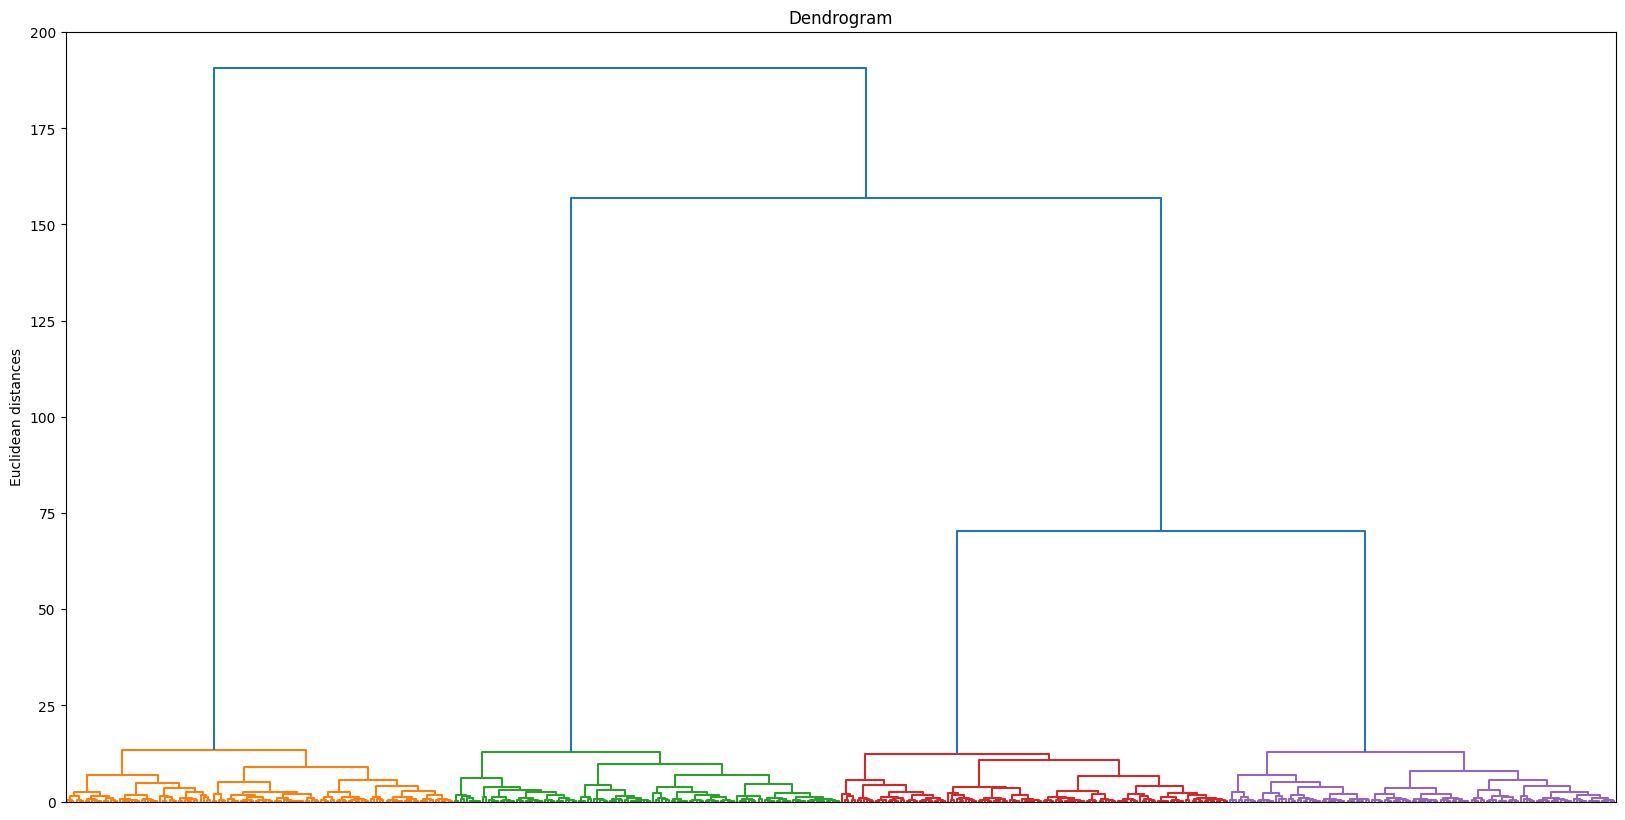

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method='ward')

plt.figure(figsize=(20, 10))
dendrogram(Z, color_threshold=50)
plt.title('Dendrogram')
plt.ylabel('Euclidean distances')
plt.xticks([]);

We can still see 4 distinct clusters  

🤔 Why did we use the *Ward method* here?

💡 Because it has the same objective function as K-means and tries to minimize inertia (i.e., within-cluster variance).

### Notes on Hierarchical Clustering

👉 Watch this video to better understand hierarchical clustering: https://www.youtube.com/watch?v=7xHsRkOdVwo

👉 Hierarchical clustering is considered *greedy*, meaning it can yield a locally optimal result and miss the bigger picture.

👉 Keep in mind that there are other clustering linkages (i.e., other ways to measure the distance between two clusters). <img src=https://editor.analyticsvidhya.com/uploads/40351linkages.PNG>